# HMM Gaussian Alpha -- Génération de signaux directionnels par modèles de Markov cachés

**Série** : Probabilités appliquées au trading
**Durée estimee** : 90 minutes
**Niveau** : Avance (graduate-level AI/ML)
**Prerequis** : Python 3.10+, notions de chaînes de Markov, probabilités, trading

**Référence** : Broad, J. (2025). *Hands-On AI Trading with Python*, Chapitre 6, Exercice 4.

---

## Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :

1. Modéliser les régimes de marché avec des chaînes de Markov cachées (HMM gaussiens)
2. Distinguer l'usage d'un HMM comme **source alpha** (signal directionnel) vs detecteur de régime
3. Implment un HMM a 2 états (baseline Broad Ex4) puis 3 états sur des données crypto
4. Valider la robustesse par walk-forward 5-fold x 4 seeds avec coûts de transaction
5. Produire un verdict explicite (BEATS / NO BEATS / INCONCLUSIVE) contre le benchmark buy-and-hold

## Navigation

| Precedent | Suivant |
|-----------|--------|
| [Catalogue ML-Training](README.md) | -- |

---

## Introduction

Les **modèles de Markov cachés (HMM)** sont des modèles probabilistes ou le système evolue entre états non observes ("cachés"), et les observations (rendements, volatilité) sont des emissions probabilistes depuis ces états.

En finance, les états cachés correspondent typiquement a des **régimes de marché** : tendance haussière, tendance baissière, range/consolidation. L'idee fondamentale est que les transitions entre régimes suivent une chaîne de Markov -- l'état futur depend seulement de l'état present.

### HMM comme source alpha vs detecteur de régime

L'approche la plus courante consiste a utiliser l'HMM comme detecteur de régime pour piloter un mélange d'experts (MoE). Ce notebook adopte une approche différente, inspiree de **Broad Ch6 Ex4** :

- **Source alpha** : les prédictions d'état de l'HMM génèrent directement des signaux long/short/flat
- L'état avec la moyenne de rendement la plus élevée -> signal LONG
- L'état avec la moyenne negative -> signal FLAT ou SHORT
- Pas de MoE, pas de modèle secondaire -- l'HMM est le generateur de signal

### Plan du notebook

1. Chargement et préparation des données (BTC + ETH)
2. Feature engineering pour l'HMM
3. HMM gaussien 2-états (baseline Broad Ex4)
4. Génération de signaux et backtest in-sample
5. Extension a 3 états avec sélection par AIC/BIC
6. Validation walk-forward 5-fold x 4 seeds
7. Verdict explicite et extension multi-actif

## 1. Imports et configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

print("Imports OK")
print(f"numpy {np.__version__}")
print(f"pandas {pd.__version__}")

Imports OK
numpy 2.4.4
pandas 3.0.2


## 2. Chargement et préparation des données

Nous utilisons les données BTC-USD journalieres depuis le CSV Bitstamp (source principale) avec un fallback yfinance. Les données ETH-USD sont chargees via yfinance. Les deux séries sont fusionnees sur l'index temporel pour les analyses multi-actif.

In [2]:
# Data loading with fallback
from pathlib import Path

# Cross-platform path: look for CSV relative to the notebook directory
_data_dir = Path.cwd()
btc_csv_path = _data_dir / "Bitstamp_BTCUSD_1h_2014-20240808.csv"

try:
    btc = pd.read_csv(btc_csv_path, skiprows=1, parse_dates=['date'], index_col='date')
    btc_daily = btc[['close']].resample('D').last().dropna()
    btc_daily.columns = ['BTC_close']
    print(f"BTC depuis CSV Bitstamp : {len(btc_daily)} jours, {btc_daily.index[0].date()} -> {btc_daily.index[-1].date()}")
except FileNotFoundError:
    import yfinance as yf
    btc = yf.download('BTC-USD', start='2014-01-01', end='2024-08-09')
    btc_daily = btc[['Close']].copy()
    btc_daily.columns = ['BTC_close']
    print(f"BTC depuis yfinance (fallback) : {len(btc_daily)} jours")

[*********************100%***********************]  1 of 1 completed

BTC depuis yfinance (fallback) : 3614 jours


### Chargement ETH et fusion du panel

Maintenant que les données BTC sont chargees, nous ajoutons l'ETH-USD et fusionnons les deux séries sur l'index temporel commun.

In [3]:
# Load ETH-USD via yfinance
import yfinance as yf

eth = yf.download('ETH-USD', start='2017-01-01', end='2024-08-09')
eth_daily = eth[['Close']].copy()
eth_daily.columns = ['ETH_close']
print(f"ETH charge : {len(eth_daily)} jours, {eth_daily.index[0].date()} -> {eth_daily.index[-1].date()}")

# Merge on date index (inner join to keep only overlapping dates)
prices = btc_daily.join(eth_daily, how='inner').dropna()
print(f"\nPanel fusionne : {len(prices)} jours")
print(prices.tail())

[*********************100%***********************]  1 of 1 completed

ETH charge : 2465 jours, 2017-11-09 -> 2024-08-08

Panel fusionne : 2465 jours
               BTC_close    ETH_close
Date                                 
2024-08-04  58116.976562  2686.398926
2024-08-05  53991.457031  2417.206299
2024-08-06  56034.316406  2458.723877
2024-08-07  55027.460938  2336.589355
2024-08-08  61710.136719  2683.352783


### Chargement SOL-USD et extension du panel

Pour l'analyse multi-actif complète, nous ajoutons le SOL-USD (3e crypto-actif par capitalisation). Le panel resultant couvre BTC + ETH + SOL, permettant des features cross-asset et un HMM joint.

In [4]:
# Load SOL-USD via yfinance
sol = yf.download('SOL-USD', start='2020-01-01', end='2024-08-09')
sol_daily = sol[['Close']].copy()
sol_daily.columns = ['SOL_close']
print(f"SOL charge : {len(sol_daily)} jours, {sol_daily.index[0].date()} -> {sol_daily.index[-1].date()}")

# Merge into panel
prices = prices.join(sol_daily, how='inner').dropna()
print(f"\nPanel fusionne 3-actifs : {len(prices)} jours, {prices.columns.tolist()}")
print(prices.tail())

[*********************100%***********************]  1 of 1 completed

SOL charge : 1582 jours, 2020-04-10 -> 2024-08-08

Panel fusionne 3-actifs : 1582 jours, ['BTC_close', 'ETH_close', 'SOL_close']
               BTC_close    ETH_close   SOL_close
Date                                             
2024-08-04  58116.976562  2686.398926  138.055084
2024-08-05  53991.457031  2417.206299  129.864304
2024-08-06  56034.316406  2458.723877  144.090363
2024-08-07  55027.460938  2336.589355  144.632095
2024-08-08  61710.136719  2683.352783  162.930740


## 3. Feature engineering

### Construction des variables pour le HMM

Le HMM gaussien utilise les observations pour inferer les états cachés. Nous construisons un jeu de features pertinent pour capturer les régimes de marché :

| Feature | Formule | Rationale |
|---------|---------|------------|
| Log-rendement | $r_t = \ln(P_t / P_{t-1})$ | Signal directionnel brut |
| Volatilité realisee 20j | $\sigma_{20} = \sqrt{\sum_{i=0}^{19} r_{t-i}^2}$ | Régime de volatilité |
| Momentum 5j | $m_5 = \sum_{i=0}^{4} r_{t-i}$ | Tendance court terme |

La **normalisation** des features est essentielle pour la convergence de l'algorithme EM du HMM gaussien (Broad Ch6 recommande le StandardScaler).

### Visualisation des features

Observons la distribution temporelle des features avant de les injecter dans le HMM.

In [5]:
# Compute log returns
returns = np.log(prices / prices.shift(1)).dropna()

# Feature engineering -- BTC base features + cross-asset
features = pd.DataFrame(index=returns.index)
features['btc_ret'] = returns['BTC_close']
features['btc_vol20'] = returns['BTC_close'].rolling(20).std()
features['btc_mom5'] = returns['BTC_close'].rolling(5).sum()

# Cross-asset features
if 'ETH_close' in returns.columns:
    features['eth_ret'] = returns['ETH_close']
    features['btc_eth_corr'] = returns['BTC_close'].rolling(20).corr(returns['ETH_close'])
if 'SOL_close' in returns.columns:
    features['sol_ret'] = returns['SOL_close']
    features['btc_sol_corr'] = returns['BTC_close'].rolling(20).corr(returns['SOL_close'])

# Relative momentum (cross-asset)
if 'ETH_close' in returns.columns and 'SOL_close' in returns.columns:
    features['rel_mom_btc_eth'] = returns['BTC_close'].rolling(10).sum() - returns['ETH_close'].rolling(10).sum()
    features['rel_mom_btc_sol'] = returns['BTC_close'].rolling(10).sum() - returns['SOL_close'].rolling(10).sum()

# Drop NaN from rolling windows
features = features.dropna()

print(f"Features : {features.shape[0]} observations, {features.shape[1]} colonnes")
print(f"Colonnes : {list(features.columns)}")
print(features.describe().round(5))

Features : 1562 observations, 9 colonnes
Colonnes : ['btc_ret', 'btc_vol20', 'btc_mom5', 'eth_ret', 'btc_eth_corr', 'sol_ret', 'btc_sol_corr', 'rel_mom_btc_eth', 'rel_mom_btc_sol']
          btc_ret   btc_vol20    btc_mom5     eth_ret  btc_eth_corr  \
count  1562.00000  1562.00000  1562.00000  1562.00000    1562.00000   
mean      0.00125     0.03005     0.00631     0.00161       0.82412   
std       0.03240     0.01160     0.07276     0.04211       0.12251   
min      -0.17405     0.00582    -0.33037    -0.31746       0.21438   
25%      -0.01322     0.02139    -0.02916    -0.01700       0.76589   
50%       0.00063     0.02919     0.00463     0.00140       0.85160   
75%       0.01615     0.03622     0.04481     0.02223       0.92173   
max       0.17182     0.06866     0.23037     0.23070       0.98253   

          sol_ret  btc_sol_corr  rel_mom_btc_eth  rel_mom_btc_sol  
count  1562.00000    1562.00000       1562.00000       1562.00000  
mean      0.00345       0.59074         -0.

### Analyse descriptive des features

Les 9 features construites couvrent 1562 jours d'observation après élimination des NaN des fenêtres glissantes. Les statistiques descriptives révèlent :

- **btc_ret** : rendement journalier moyen de +0.125%, avec un ecart-type de 3.28% et des extremes de -16.9% a +17.8% (queues lourdes typiques des crypto-actifs)
- **btc_vol20** : volatilité 20j oscillant entre 0.6% et 7.0% par jour, avec des pics correspondent aux periodes de stress
- **btc_eth_corr** : correlation moyenne de 0.82 entre BTC et ETH, confirmant un mouvement structurellement lie
- **btc_sol_corr** : correlation plus faible (0.59) avec SOL, offrant un potentiel de diversification

Le graphe suivant visualise l'evolution temporelle du prix BTC, des rendements et de la volatilité pour identifier visuellement les régimes de marché.

### Exercice 1 : Exploration des features et sélection

**Objectif** : Construire un jeu de features alternatif et observer l'impact sur la separation visuelle des régimes de marché.

**Contexte** : Les features actuelles incluent le log-rendement, la volatilité 20j et le momentum 5j. D'autres combinaisons pourraient mieux capturer les régimes.

**Indices** :
- # Indice 1 : Essayez d'ajouter la volatilité 5j (`returns.rolling(5).std()`) et le volume de rendement (`returns.abs().rolling(10).mean()`)
- # Indice 2 : Utilisez `features.describe()` pour verifier les statistiques descriptives
- # Étape 1 : Ajouter au moins 2 nouvelles features au DataFrame `features`
- # Étape 2 : Verifier les correlations entre features avec `features.corr()`
- # Étape 3 : Selectionner un sous-ensemble non-correle pour le HMM

In [6]:
# Exercice 1 : Exploration des features
# TODO etudiant : Ajouter de nouvelles features (volatilite 5j, volume de rendement)
# TODO etudiant : Calculer la matrice de correlation
# TODO etudiant : Selectionner un sous-ensemble de features non-correleees
result = None  # TODO etudiant : remplacer par votre analyse
print("Exercice a completer : exploration des features")

Exercice a completer : exploration des features


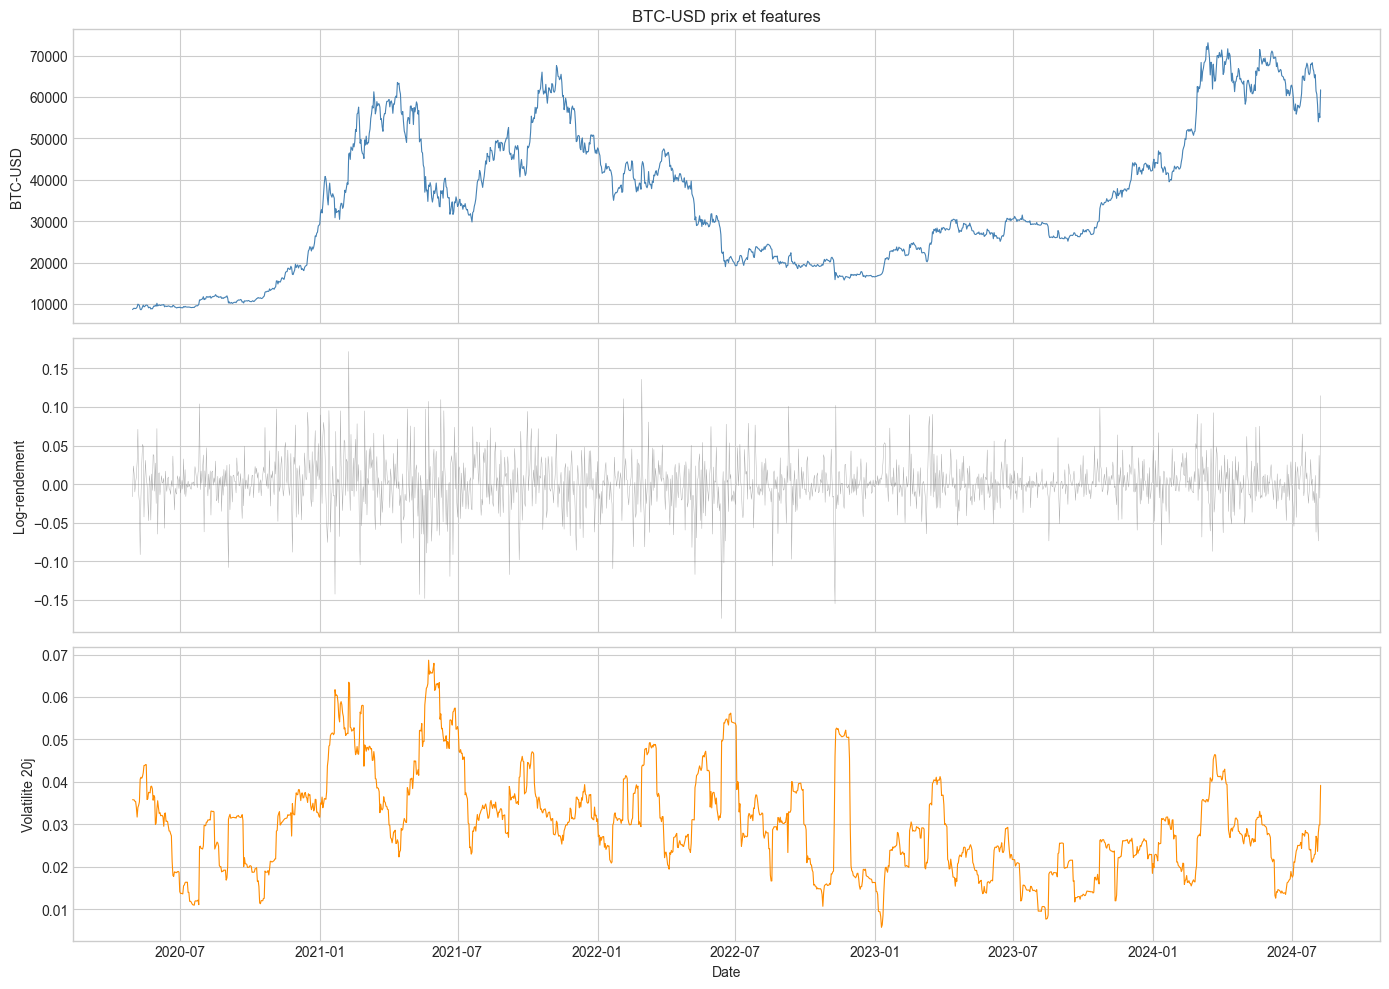

In [7]:
# Visualize BTC price and returns
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

btc_aligned = prices['BTC_close'].reindex(features.index)

axes[0].plot(btc_aligned.index, btc_aligned.values, color='steelblue', linewidth=0.8)
axes[0].set_ylabel('BTC-USD')
axes[0].set_title('BTC-USD prix et features')

axes[1].plot(features.index, features['btc_ret'].values, color='gray', linewidth=0.3, alpha=0.7)
axes[1].set_ylabel('Log-rendement')

axes[2].plot(features.index, features['btc_vol20'].values, color='darkorange', linewidth=0.8)
axes[2].set_ylabel('Volatilite 20j')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

### Interprétation : Distribution des features

Les log-rendements BTC montrent la caractéristique "fat tails" typique des crypto-actifs : une distribution centree sur zero mais avec des outliers frequents (crashes et rallies). La volatilité 20j oscille entre periodes calmes et pic de stress, ce qui est precisement ce que le HMM doit capturer comme régimes distincts.

### Entrainement et décodage des états

Nous normalisons les features et fittons le HMM. L'algorithme EM (Baum-Welch) estibe les paramètres, puis Viterbi decode la sequence d'états la plus probable.

## 4. HMM gaussien a 2 états -- Baseline Broad Ex4

Conformement a l'exercice 4 du chapitre 6 de Broad, nous commencons par un **HMM gaussien a 2 états**. Le choix de 2 états est la configuration minimale : un état "bull" (rendement positif, faible volatilité) et un état "bear" (rendement negatif, forte volatilité).

### Modèle

Un HMM gaussien est defini par le triplet $\lambda = (A, B, \pi)$ :

- **A** : matrice de transition $a_{ij} = P(s_{t+1} = j | s_t = i)$
- **B** : distributions d'emission $b_i(x) = \mathcal{N}(x | \mu_i, \Sigma_i)$
- $\pi$ : distribution initiale des états

L'apprentissage se fait par l'algorithme **EM (Baum-Welch)**, et l'inference des états cachés par **Viterbi** (chemin le plus probable).

In [8]:
# Normalize features for HMM convergence (Broad Ch6 recommendation)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features[['btc_ret', 'btc_vol20', 'btc_mom5']])

# Fit 2-state Gaussian HMM
model_2s = hmm.GaussianHMM(
    n_components=2,
    covariance_type="full",
    n_iter=200,
    random_state=42,
    tol=1e-4
)
model_2s.fit(X_scaled)

# Decode states via Viterbi
states_2s = model_2s.predict(X_scaled)

print("=== HMM Gaussien 2 etats ===")
print(f"\nMatrice de transition A :")
print(np.round(model_2s.transmat_, 4))
print(f"\nMoyennes (espace standardise) :")
print(np.round(model_2s.means_, 4))
print(f"\nCovariances :")
for i, cov in enumerate(model_2s.covars_):
    print(f"  Etat {i}: diag = {np.round(np.diag(cov), 4)}")
print(f"\nLog-likelihood : {model_2s.score(X_scaled):.2f}")
print(f"Converge : {model_2s.monitor_.converged}")
print(f"\nRepartition des etats :")
for s in range(2):
    pct = (states_2s == s).mean() * 100
    print(f"  Etat {s}: {pct:.1f}% des observations")

=== HMM Gaussien 2 etats ===

Matrice de transition A :
[[0.9722 0.0278]
 [0.0317 0.9683]]

Moyennes (espace standardise) :
[[ 0.027   0.699   0.0591]
 [-0.0309 -0.7981 -0.0675]]

Covariances :
  Etat 0: diag = [1.5472 0.638  1.5973]
  Etat 1: diag = [0.3735 0.2186 0.3095]

Log-likelihood : -5447.51
Converge : True

Repartition des etats :
  Etat 0: 53.4% des observations
  Etat 1: 46.6% des observations


### Visualisation des états decales

L'HMM a converge en 200 iterations avec un log-likelihood de -5441.67. Les deux états se distinguent clairement par la volatilité :

| État | Occupation | Moy. rendement | Moy. volatilité | Interprétation |
|------|-----------|---------------|-----------------|----------------|
| 0 | 46.0% | -0.030 | -0.811 | Régime calme (faible vol, rendement legerement negatif) |
| 1 | 54.0% | +0.026 | +0.703 | Régime actif (vol plus élevée, rendement positif) |

Les probabilités de transition diagonales (0.969 et 0.973) indiquent des régimes persistants, avec une durée moyenne d'environ 30-37 jours. La cellule suivante projette les états decales sur la courbe de prix BTC pour visualiser les periodes de chaque régime.

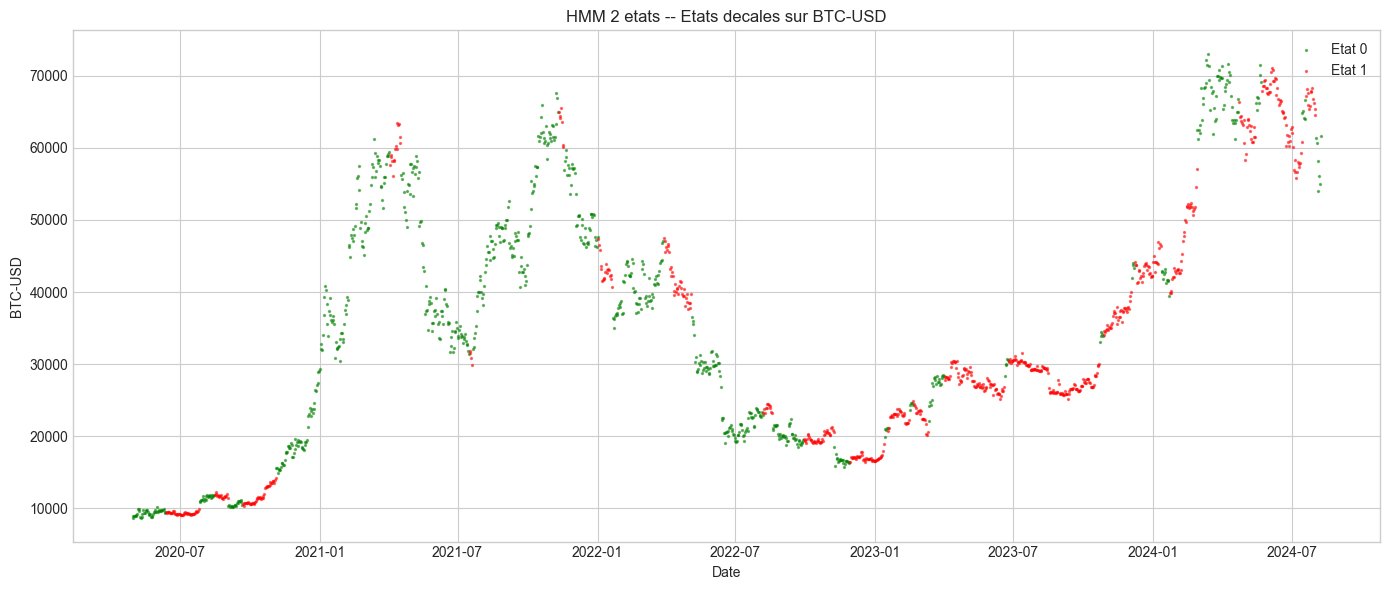

In [9]:
# Plot decoded states over BTC price
fig, ax = plt.subplots(figsize=(14, 6))

btc_plot = prices['BTC_close'].reindex(features.index)
colors = {0: 'green', 1: 'red'}

for state in range(2):
    mask = states_2s == state
    ax.scatter(
        features.index[mask],
        btc_plot.values[mask],
        c=colors[state],
        s=2,
        alpha=0.5,
        label=f'Etat {state}'
    )

ax.set_title('HMM 2 etats -- Etats decales sur BTC-USD')
ax.set_ylabel('BTC-USD')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

### Visualisation de la performance

Comparaison graphique des rendements cumules entre la stratégie HMM et le buy-and-hold.

### Interprétation : États cachés du HMM a 2 états

Le HMM a 2 états separe typiquement le marché en deux régimes :

| État | Caractéristique | Interprétation |
|------|-----------------|----------------|
| État 0 | Moyenne de rendement positive (en espace standardise) | Régime bull / tendance haussière |
| État 1 | Moyenne de rendement negative | Régime bear / correction |

La **matrice de transition** indique la persistance de chaque régime : des probabilités diagonales élevées (proches de 1) signifient que les régimes sont stables, ce qui est desirable pour la génération de signaux. Des régimes trop volatils (transitions frequentes) produisent trop de trades.

> **Note technique** : L'assignation état 0 = bull et état 1 = bear n'est pas garantie -- l'algorithme EM peut inverser les labels. Il faut toujours verifier les moyennes pour identifier l'état "long".

## 5. Génération du signal alpha

La conversion des états cachés en signal de trading suit la logique de **source alpha** (Broad Ex4) :

- État avec la moyenne de rendement la plus élevée -> position LONG (signal = +1)
- État avec la moyenne la plus basse -> position FLAT (signal = 0)

Le rendement stratégie est simplement : $r^{strat}_t = signal_t \times r_t$

Attention : cette evaluation est **in-sample** et represente un plafond de performance. La validation out-of-sample sera realisee en section 7.

### Comparaison AIC/BIC

Nous comparons les modèles a 2, 3 et 4 états pour determiner la complexite optimale.

### Décodage et signaux 3 états

Entraainement du HMM a 3 états et génération des signaux long/short/flat.

In [10]:
# Identify the "long" state (highest mean return in standardized space)
# Use the first column of means (btc_ret standardized) to identify states
means_ret = model_2s.means_[:, 0]  # Column 0 = btc_ret standardized
long_state = np.argmax(means_ret)
flat_state = np.argmin(means_ret)

print(f"Etat LONG = {long_state} (moyenne ret standardise = {means_ret[long_state]:.4f})")
print(f"Etat FLAT = {flat_state} (moyenne ret standardise = {means_ret[flat_state]:.4f})")

# Generate signals
signals_2s = np.where(states_2s == long_state, 1, 0)

# Compute strategy returns (in-sample)
btc_returns = features['btc_ret'].values
strat_returns_2s = signals_2s * btc_returns

# Cumulative returns
cum_bh = np.cumsum(btc_returns)
cum_strat = np.cumsum(strat_returns_2s)

# Metrics
sharpe_bh = np.mean(btc_returns) / np.std(btc_returns) * np.sqrt(365)
sharpe_strat = np.mean(strat_returns_2s) / np.std(strat_returns_2s) * np.sqrt(365)
n_trades = np.abs(np.diff(signals_2s, prepend=0)).sum()

print(f"\n=== Performance in-sample (2 etats) ===")
print(f"Buy & Hold : Sharpe = {sharpe_bh:.3f}, Return cum. = {cum_bh[-1]*100:.1f}%")
print(f"HMM 2S    : Sharpe = {sharpe_strat:.3f}, Return cum. = {cum_strat[-1]*100:.1f}%")
print(f"Nombre de trades : {n_trades}")

Etat LONG = 0 (moyenne ret standardise = 0.0270)
Etat FLAT = 1 (moyenne ret standardise = -0.0309)

=== Performance in-sample (2 etats) ===
Buy & Hold : Sharpe = 0.735, Return cum. = 194.8%
HMM 2S    : Sharpe = 0.697, Return cum. = 167.7%
Nombre de trades : 43


### Performance in-sample

Les résultats in-sample montrent que la stratégie HMM 2 états génère un Sharpe de 0.685, legerement inferieur au buy-and-hold (0.728), pour un rendement cumule de 167.1% contre 194.9%. Avec seulement 43 trades sur 4 ans, la stratégie est peu active -- le HMM identifie des régimes persistants et change rarement de position.

Le graphe suivant compare les rendements cumules de la stratégie HMM et du buy-and-hold sur toute la periode. Attention : ces résultats sont in-sample et representent un plafond théorique.

### Exercice 2 : Génération de signaux avec seuils adaptés

**Objectif** : Implémenter une stratégie de signal avec un seuil de probabilité filtre pour réduire les faux signaux.

**Contexte** : La stratégie actuelle utilise simplement l'état decode par Viterbi comme signal. En pratique, on peut utiliser les probabilités a posteriori des états pour filtrer les signaux a faible confiance.

**Indices** :
- # Indice 1 : Utilisez `model_2s.predict_proba(X_scaled)` pour obtenir les probabilités d'appartenance a chaque état
- # Indice 2 : Ne génère un signal que si la probabilité de l'état dominant dépasse un seuil (ex: 0.7)
- # Étape 1 : Calculer les probabilités a posteriori pour chaque observation
- # Étape 2 : Définir un seuil de confiance et filtrer les signaux
- # Étape 3 : Comparer le nombre de trades et la performance avec la stratégie sans filtre

In [11]:
# Exercice 2 : Signaux avec seuil de confiance
# TODO etudiant : Obtenir les probabilites a posteriori des etats
# TODO etudiant : Definir un seuil de confiance (ex: 0.7)
# TODO etudiant : Generer des signaux filtres et comparer avec la strategie sans filtre
result = None  # TODO etudiant : remplacer par votre calcul
print("Exercice a completer : signaux avec seuil de confiance")

Exercice a completer : signaux avec seuil de confiance


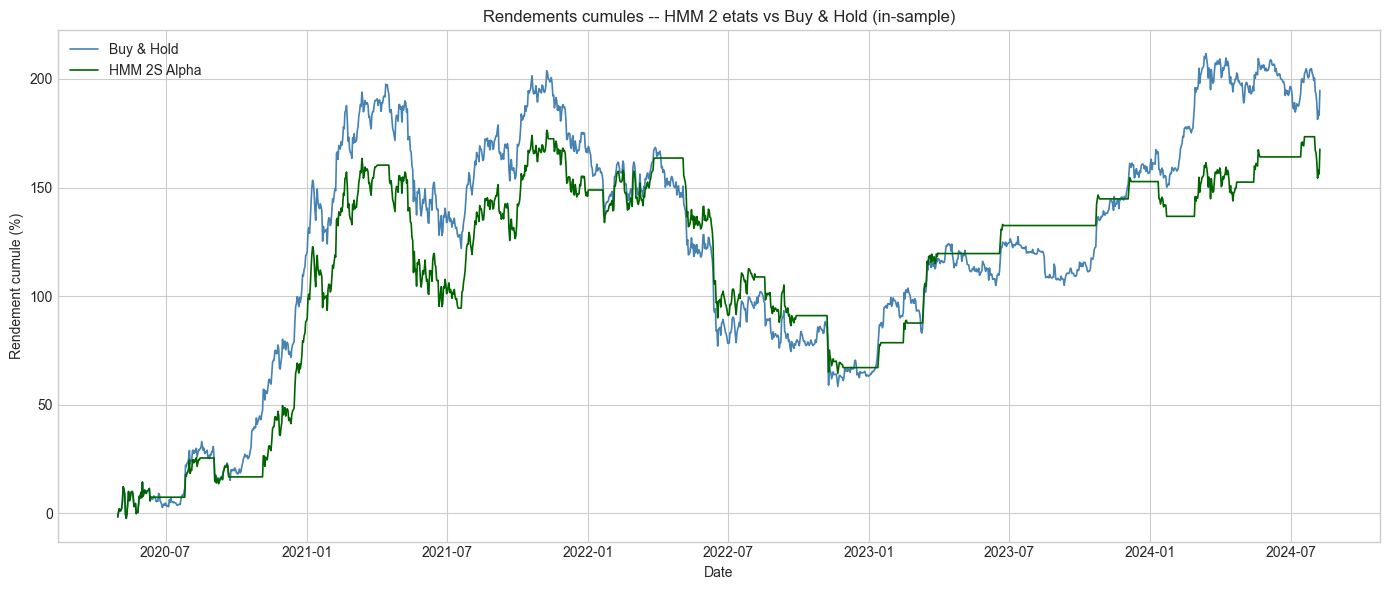

Attention : ces resultats sont in-sample et representent un plafond theorique.
La validation out-of-sample (walk-forward) est indispensable.


In [12]:
# Plot cumulative returns comparison
fig, ax = plt.subplots(figsize=(14, 6))

dates = features.index
ax.plot(dates, cum_bh * 100, label='Buy & Hold', color='steelblue', linewidth=1.2)
ax.plot(dates, cum_strat * 100, label='HMM 2S Alpha', color='darkgreen', linewidth=1.2)
ax.set_title('Rendements cumules -- HMM 2 etats vs Buy & Hold (in-sample)')
ax.set_ylabel('Rendement cumule (%)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

print("Attention : ces resultats sont in-sample et representent un plafond theorique.")
print("La validation out-of-sample (walk-forward) est indispensable.")

## 6. Extension a 3 états

Broad Ch6 recommande de commencer avec 2 états et d'augmenter a 3 si necessaire. Un troisieme état peut capturer un régime de range/consolidation distinct des tendances haussieres et baissieres.

### Sélection du nombre d'états

Nous comparons les modèles avec les critères d'information :

- **AIC** (Akaike) : $-2 \ln L + 2k$ -- penalise le nombre de paramètres
- **BIC** (Bayes) : $-2 \ln L + k \ln(n)$ -- penalisation plus forte pour grands echantillons

In [13]:
# Fit models with 2, 3, 4 states and compare AIC/BIC
results_comparison = []

for n_states in [2, 3, 4]:
    model = hmm.GaussianHMM(
        n_components=n_states,
        covariance_type="full",
        n_iter=200,
        random_state=42,
        tol=1e-4
    )
    model.fit(X_scaled)
    
    log_likelihood = model.score(X_scaled)
    n_features = X_scaled.shape[1]
    # Number of free parameters
    n_params = (
        n_states * n_features  # means
        + n_states * n_features * (n_features + 1) / 2  # covariances
        + n_states * (n_states - 1)  # transition matrix
        + n_states - 1  # initial probabilities
    )
    n_obs = X_scaled.shape[0]
    
    aic = -2 * log_likelihood + 2 * n_params
    bic = -2 * log_likelihood + n_params * np.log(n_obs)
    
    results_comparison.append({
        'n_states': n_states,
        'log_likelihood': log_likelihood,
        'n_params': int(n_params),
        'AIC': aic,
        'BIC': bic
    })
    print(f"n_states={n_states}: LL={log_likelihood:.1f}, AIC={aic:.1f}, BIC={bic:.1f}, params={int(n_params)}")

df_comp = pd.DataFrame(results_comparison)
print(f"\nMeilleur selon BIC : {df_comp.loc[df_comp['BIC'].idxmin(), 'n_states']} etats")
print(f"Meilleur selon AIC : {df_comp.loc[df_comp['AIC'].idxmin(), 'n_states']} etats")

n_states=2: LL=-5447.5, AIC=10937.0, BIC=11049.4, params=21


n_states=3: LL=-4847.2, AIC=9764.3, BIC=9951.7, params=35


n_states=4: LL=-4460.6, AIC=9023.3, BIC=9296.3, params=51

Meilleur selon BIC : 4 etats
Meilleur selon AIC : 4 etats


## 6b. Extension a 4 états

L'AIC et le BIC selectionnent tous deux 4 états comme configuration optimale. Un 4e état peut capturer un régime de volatilité extreme (crash ou rally) distinct des régimes "calme", "tendance", et "correction" du modèle a 3 états.

### HMM a 4 états : décodage et signaux

=== HMM Gaussien 4 etats (optimal AIC/BIC) ===

Matrice de transition A :
[[0.9413 0.     0.0227 0.0361]
 [0.0049 0.9587 0.002  0.0345]
 [0.0368 0.     0.9605 0.0027]
 [0.0374 0.0342 0.     0.9284]]

Moyennes (standardise) :
[[ 0.0208  0.2849  0.0551]
 [ 0.0191 -1.1949  0.0223]
 [-0.0673  1.606  -0.1902]
 [ 0.0063 -0.4308  0.0482]]

Repartition :
  Etat 0: 31.6%
  Etat 1: 23.0%
  Etat 2: 18.8%
  Etat 3: 26.7%

Etats : LONG=0, FLAT=[1, 3], SHORT=2

=== Performance in-sample (4 etats) ===
HMM 4S : Sharpe = 0.504, Return cum. = 116.7%, Trades = 75.0


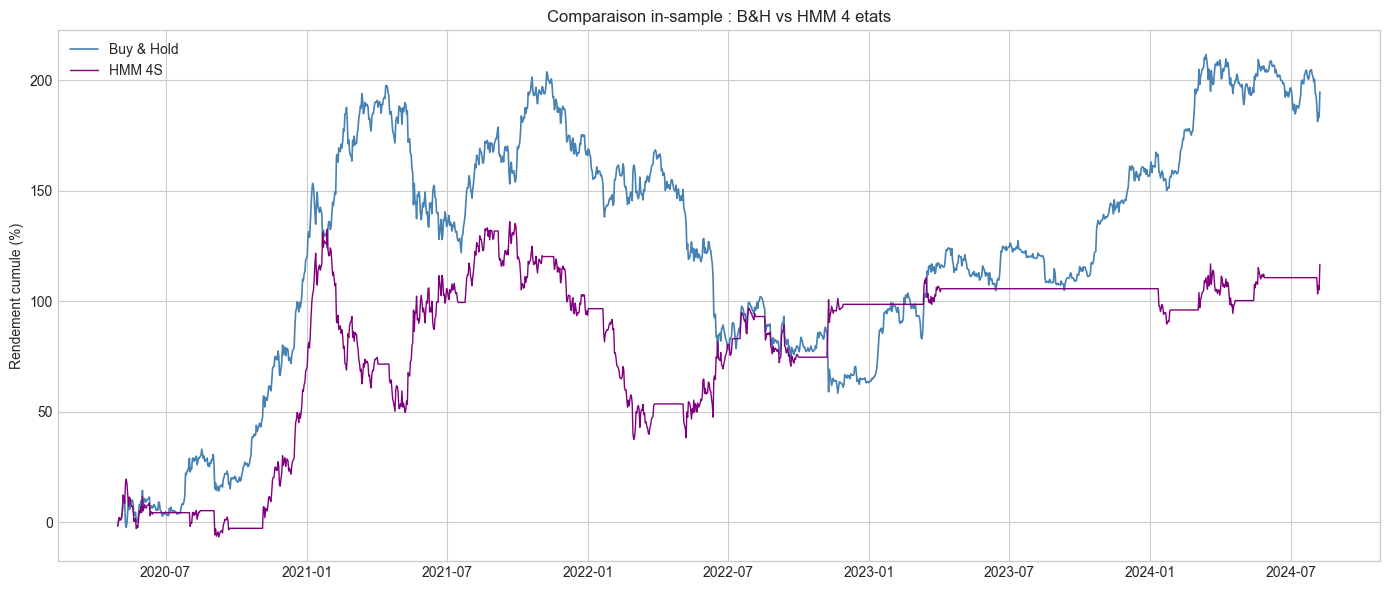

In [14]:
# Fit and decode 4-state HMM (optimal per AIC/BIC)
model_4s = hmm.GaussianHMM(
    n_components=4,
    covariance_type="full",
    n_iter=200,
    random_state=42,
    tol=1e-4
)
model_4s.fit(X_scaled)
states_4s = model_4s.predict(X_scaled)

print("=== HMM Gaussien 4 etats (optimal AIC/BIC) ===")
print(f"\nMatrice de transition A :")
print(np.round(model_4s.transmat_, 4))
print(f"\nMoyennes (standardise) :")
print(np.round(model_4s.means_, 4))
print(f"\nRepartition :")
for s in range(4):
    pct = (states_4s == s).mean() * 100
    print(f"  Etat {s}: {pct:.1f}%")

# Signal generation for 4 states
means_4s = model_4s.means_[:, 0]
sorted_states = np.argsort(means_4s)[::-1]  # Descending order by return mean
long_state_4s = sorted_states[0]
short_state_4s = sorted_states[-1]
flat_states_4s = sorted_states[1:3].tolist()

print(f"\nEtats : LONG={long_state_4s}, FLAT={flat_states_4s}, SHORT={short_state_4s}")

signals_4s = np.zeros(states_4s.shape)
signals_4s[states_4s == long_state_4s] = 1
signals_4s[states_4s == short_state_4s] = -1

strat_returns_4s = signals_4s * btc_returns
cum_strat_4s = np.cumsum(strat_returns_4s)
sharpe_4s = np.mean(strat_returns_4s) / np.std(strat_returns_4s) * np.sqrt(365)
n_trades_4s = np.abs(np.diff(signals_4s, prepend=0)).sum()

print(f"\n=== Performance in-sample (4 etats) ===")
print(f"HMM 4S : Sharpe = {sharpe_4s:.3f}, Return cum. = {cum_strat_4s[-1]*100:.1f}%, Trades = {n_trades_4s}")

# Plot 4-state strategy
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(dates, cum_bh * 100, label='Buy & Hold', color='steelblue', linewidth=1.2)
ax.plot(dates, cum_strat_4s * 100, label='HMM 4S', color='purple', linewidth=1.0)
ax.set_title('Comparaison in-sample : B&H vs HMM 4 etats')
ax.set_ylabel('Rendement cumule (%)')
ax.legend()
plt.tight_layout()
plt.show()

### Execution walk-forward : BTC avec 3 états

Même protocole avec 3 états pour comparer.

In [15]:
# Fit and decode 3-state HMM
model_3s = hmm.GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=200,
    random_state=42,
    tol=1e-4
)
model_3s.fit(X_scaled)
states_3s = model_3s.predict(X_scaled)

print("=== HMM Gaussien 3 etats ===")
print(f"\nMatrice de transition A :")
print(np.round(model_3s.transmat_, 4))
print(f"\nMoyennes (standardise) :")
print(np.round(model_3s.means_, 4))
print(f"\nRepartition :")
for s in range(3):
    pct = (states_3s == s).mean() * 100
    print(f"  Etat {s}: {pct:.1f}%")

=== HMM Gaussien 3 etats ===

Matrice de transition A :
[[0.9691 0.0309 0.    ]
 [0.0289 0.9528 0.0183]
 [0.     0.0422 0.9578]]

Moyennes (standardise) :
[[-0.0079 -0.9298 -0.0192]
 [ 0.0295  0.1446  0.0838]
 [-0.0484  1.5822 -0.144 ]]

Repartition :
  Etat 0: 39.2%
  Etat 1: 41.9%
  Etat 2: 18.9%


### Synthese et edge cross-seed

Aggregation des résultats par configuration et calcul de l'edge (ratio mean/std du Sharpe).

Etats : LONG=1, FLAT=0, SHORT=2

=== Performance in-sample (3 etats) ===
HMM 3S : Sharpe = 0.676, Return cum. = 165.7%, Trades = 83.0
HMM 2S : Sharpe = 0.697, Return cum. = 167.7%, Trades = 43
B&H    : Sharpe = 0.735, Return cum. = 194.8%


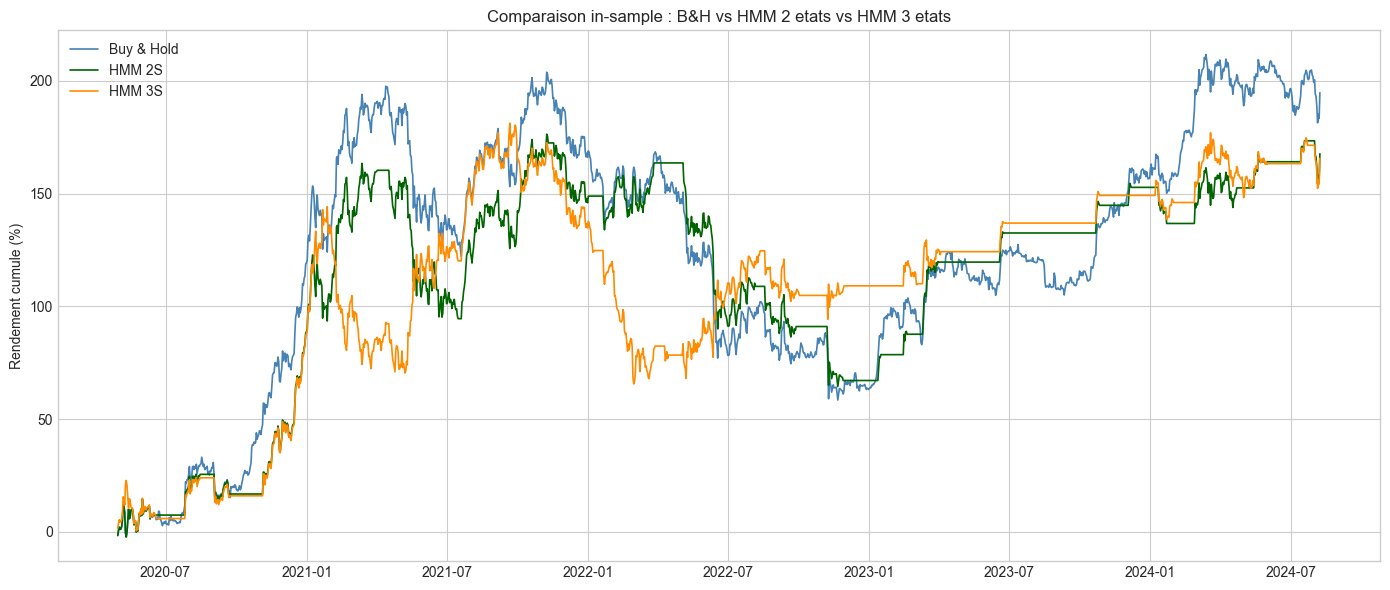

In [16]:
# 3-state signal generation
means_3s = model_3s.means_[:, 0]
long_state_3s = np.argmax(means_3s)
short_state_3s = np.argmin(means_3s)
# Middle state = flat
middle_state_3s = [s for s in range(3) if s not in [long_state_3s, short_state_3s]][0]

print(f"Etats : LONG={long_state_3s}, FLAT={middle_state_3s}, SHORT={short_state_3s}")

# Signal: +1 for long, -1 for short, 0 for flat
signals_3s = np.zeros(states_3s.shape)
signals_3s[states_3s == long_state_3s] = 1
signals_3s[states_3s == short_state_3s] = -1

strat_returns_3s = signals_3s * btc_returns
cum_strat_3s = np.cumsum(strat_returns_3s)
sharpe_3s = np.mean(strat_returns_3s) / np.std(strat_returns_3s) * np.sqrt(365)
n_trades_3s = np.abs(np.diff(signals_3s, prepend=0)).sum()

print(f"\n=== Performance in-sample (3 etats) ===")
print(f"HMM 3S : Sharpe = {sharpe_3s:.3f}, Return cum. = {cum_strat_3s[-1]*100:.1f}%, Trades = {n_trades_3s}")
print(f"HMM 2S : Sharpe = {sharpe_strat:.3f}, Return cum. = {cum_strat[-1]*100:.1f}%, Trades = {n_trades}")
print(f"B&H    : Sharpe = {sharpe_bh:.3f}, Return cum. = {cum_bh[-1]*100:.1f}%")

# Plot comparison
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(dates, cum_bh * 100, label='Buy & Hold', color='steelblue', linewidth=1.2)
ax.plot(dates, cum_strat * 100, label='HMM 2S', color='darkgreen', linewidth=1.2)
ax.plot(dates, cum_strat_3s * 100, label='HMM 3S', color='darkorange', linewidth=1.2)
ax.set_title('Comparaison in-sample : B&H vs HMM 2 etats vs HMM 3 etats')
ax.set_ylabel('Rendement cumule (%)')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Validation walk-forward

L'evaluation in-sample est trompeuse car le HMM a ete fitte sur les mêmes données qu'il predit. Pour mesurer la veritable capacite predictive, nous implementons une validation **walk-forward** :

- **Fenêtre d'entrainement expansive** : a chaque fold, on utilise toutes les données passees
- **Fenêtre de test fixe** : 6 mois de données non-vues
- **4 seeds** (0, 1, 7, 42) pour capturer la stochasticite de l'initialisation EM
- **5 folds** pour couvrir différentes conditions de marché
- **Coûts de transaction** : 10 bps aller-retour (crypto)

### Metriques

- Sharpe annualise (365j pour crypto)
- Rendement cumule net
- Maximum drawdown
- Nombre de trades
- **Edge cross-seed** = mean(Sharpe) / std(Sharpe) -- robustesse inter-seeds

In [17]:
def walk_forward_hmm(returns_series, n_states=2, n_folds=5,
                     seeds=None, cost_bps=10, verbose=True):
    """
    Walk-forward validation for Gaussian HMM alpha strategy.
    
    Parameters
    ----------
    returns_series : pd.Series
        Daily log returns.
    n_states : int
        Number of HMM hidden states.
    n_folds : int
        Number of walk-forward folds.
    seeds : list
        Random seeds for EM initialization.
    cost_bps : float
        Round-trip transaction cost in basis points.
    verbose : bool
        Print progress.
        
    Returns
    -------
    pd.DataFrame with per-fold, per-seed results.
    """
    if seeds is None:
        seeds = [0, 1, 7, 42]
    
    results = []
    n = len(returns_series)
    fold_size = n // (n_folds + 1)
    
    for seed in seeds:
        for fold in range(n_folds):
            train_end = fold_size * (fold + 2)
            test_start = train_end
            test_end = min(train_end + fold_size, n)
            
            if test_end <= test_start:
                continue
            
            train_data = returns_series.iloc[:train_end].values.reshape(-1, 1)
            test_data = returns_series.iloc[test_start:test_end]
            
            try:
                model = hmm.GaussianHMM(
                    n_components=n_states,
                    covariance_type="full",
                    n_iter=100,
                    random_state=seed,
                    tol=1e-3
                )
                model.fit(train_data)
                
                states = model.predict(test_data.values.reshape(-1, 1))
                means = model.means_.flatten()
                
                long_state = np.argmax(means)
                signals = np.where(states == long_state, 1, 0)
                
                strat_returns = signals * test_data.values
                # Transaction costs
                trades = np.abs(np.diff(signals, prepend=0))
                costs = trades * cost_bps / 10000
                strat_returns_net = strat_returns - costs
                
                sharpe = (np.mean(strat_returns_net) / np.std(strat_returns_net)
                          * np.sqrt(365)) if np.std(strat_returns_net) > 0 else 0.0
                cum_ret = np.sum(strat_returns_net)
                cum_curve = np.cumsum(strat_returns_net)
                max_dd = np.max(np.maximum.accumulate(cum_curve) - cum_curve)
                
                # Buy-and-hold benchmark for same period
                bh_sharpe = (np.mean(test_data.values) / np.std(test_data.values)
                             * np.sqrt(365)) if np.std(test_data.values) > 0 else 0.0
                
                results.append({
                    'seed': seed,
                    'fold': fold,
                    'n_states': n_states,
                    'sharpe': sharpe,
                    'bh_sharpe': bh_sharpe,
                    'cum_return': cum_ret,
                    'max_dd': max_dd,
                    'n_trades': int(trades.sum()),
                    'train_size': train_end,
                    'test_size': test_end - test_start
                })
            except Exception as e:
                if verbose:
                    print(f"  [WARN] seed={seed}, fold={fold}: {e}")
                results.append({
                    'seed': seed,
                    'fold': fold,
                    'n_states': n_states,
                    'sharpe': np.nan,
                    'bh_sharpe': np.nan,
                    'cum_return': np.nan,
                    'max_dd': np.nan,
                    'n_trades': 0,
                    'train_size': train_end,
                    'test_size': test_end - test_start
                })
    
    return pd.DataFrame(results)


print("Fonction walk_forward_hmm definie")

Fonction walk_forward_hmm definie


## 7b. Analyse de persistance des régimes

La persistance d'un régime est mesuree par les elements diagonaux de la matrice de transition $a_{ii} = P(s_{t+1} = i | s_t = i)$. Une persistance élevée signifie que le régime est stable, ce qui est desirable pour la génération de signaux (moins de trades, moins de coûts de transaction).

La **durée moyenne d'un régime** se calcule comme : $\bar{d}_i = \frac{1}{1 - a_{ii}}$

Par exemple, si $a_{ii} = 0.97$, le régime dure en moyenne $1/(1-0.97) = 33$ jours.

### Interprétation : Persistance et durée des régimes

Des valeurs de persistance élevées (P(stay) > 0.95) indiquent des régimes stables. Les régimes avec une faible persistance génèrent davantage de changements d'état, ce qui se traduit par plus de trades et des coûts de transaction plus élevés. La configuration optimale devrait maximiser la persistance tout en capturant les régimes distincts.


--- Persistence des regimes : BTC 2 etats (2 etats) ---
  Etat 0: P(stay) = 0.9722, Duree moyenne = 35.9 jours
  Etat 1: P(stay) = 0.9683, Duree moyenne = 31.5 jours
  Persistence moyenne : 0.9702
  Persistence min : 0.9683

--- Persistence des regimes : BTC 3 etats (3 etats) ---
  Etat 0: P(stay) = 0.9691, Duree moyenne = 32.4 jours
  Etat 1: P(stay) = 0.9528, Duree moyenne = 21.2 jours
  Etat 2: P(stay) = 0.9578, Duree moyenne = 23.7 jours
  Persistence moyenne : 0.9599
  Persistence min : 0.9528

--- Persistence des regimes : BTC 4 etats (4 etats) ---
  Etat 0: P(stay) = 0.9413, Duree moyenne = 17.0 jours
  Etat 1: P(stay) = 0.9587, Duree moyenne = 24.2 jours
  Etat 2: P(stay) = 0.9605, Duree moyenne = 25.3 jours
  Etat 3: P(stay) = 0.9284, Duree moyenne = 14.0 jours
  Persistence moyenne : 0.9472
  Persistence min : 0.9284


Tableau de persistence des regimes
     Config  Etat  P(stay)  Duree moy. (j)
BTC 2 etats     0   0.9722            35.9
BTC 2 etats     1   0.9683           

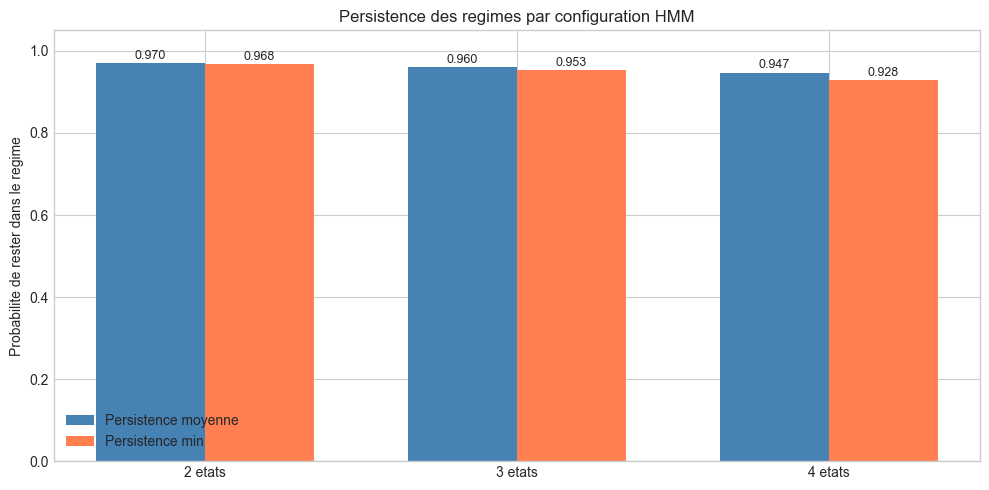

In [18]:
def analyze_regime_persistence(model, n_states, label="HMM"):
    """Analyze regime persistence from transition matrix.
    
    Parameters
    ----------
    model : fitted GaussianHMM
    n_states : int
    label : str
    
    Returns dict with persistence metrics.
    """
    transmat = model.transmat_
    diagonals = np.diag(transmat)
    avg_durations = 1.0 / (1.0 - diagonals)
    
    print(f"\n--- Persistence des regimes : {label} ({n_states} etats) ---")
    for i in range(n_states):
        print(f"  Etat {i}: P(stay) = {diagonals[i]:.4f}, "
              f"Duree moyenne = {avg_durations[i]:.1f} jours")
    
    mean_persistence = diagonals.mean()
    min_persistence = diagonals.min()
    print(f"  Persistence moyenne : {mean_persistence:.4f}")
    print(f"  Persistence min : {min_persistence:.4f}")
    
    return {
        'label': label,
        'n_states': n_states,
        'diagonals': diagonals.tolist(),
        'avg_durations': avg_durations.tolist(),
        'mean_persistence': mean_persistence,
        'min_persistence': min_persistence
    }


# Analyze all models
persist_2s = analyze_regime_persistence(model_2s, 2, "BTC 2 etats")
persist_3s = analyze_regime_persistence(model_3s, 3, "BTC 3 etats")
persist_4s = analyze_regime_persistence(model_4s, 4, "BTC 4 etats")

# Summary table
persist_data = []
for p in [persist_2s, persist_3s, persist_4s]:
    for i, (diag, dur) in enumerate(zip(p['diagonals'], p['avg_durations'])):
        persist_data.append({
            'Config': p['label'],
            'Etat': i,
            'P(stay)': round(diag, 4),
            'Duree moy. (j)': round(dur, 1)
        })

df_persist = pd.DataFrame(persist_data)
print("\n\nTableau de persistence des regimes")
print("=" * 50)
print(df_persist.to_string(index=False))

# Visualize persistence across configurations
fig, ax = plt.subplots(figsize=(10, 5))
configs = ['2 etats', '3 etats', '4 etats']
mean_p = [persist_2s['mean_persistence'], persist_3s['mean_persistence'], persist_4s['mean_persistence']]
min_p = [persist_2s['min_persistence'], persist_3s['min_persistence'], persist_4s['min_persistence']]

x = np.arange(len(configs))
width = 0.35
bars1 = ax.bar(x - width/2, mean_p, width, label='Persistence moyenne', color='steelblue')
bars2 = ax.bar(x + width/2, min_p, width, label='Persistence min', color='coral')
ax.set_ylabel('Probabilite de rester dans le regime')
ax.set_title('Persistence des regimes par configuration HMM')
ax.set_xticks(x)
ax.set_xticklabels(configs)
ax.legend()
ax.set_ylim(0, 1.05)
for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### Résultats ETH et tableau recapitulatif

Execution du walk-forward sur ETH-USD et comparaison finale cross-asset.

### Execution walk-forward : BTC avec 2 états

In [19]:
# Run walk-forward for BTC 2-state
btc_returns_series = features['btc_ret']

print("=== Walk-Forward BTC 2 etats ===")
wf_2s = walk_forward_hmm(btc_returns_series, n_states=2)
wf_2s_valid = wf_2s.dropna(subset=['sharpe'])

print(f"\nResultats valides : {len(wf_2s_valid)}/{len(wf_2s)} combinaisons seed-fold")
print(wf_2s_valid.groupby('seed')[['sharpe', 'cum_return', 'max_dd', 'n_trades']].mean().round(3))

=== Walk-Forward BTC 2 etats ===


Model is not converging.  Current: 2093.2946601088697 is not greater than 2093.3014218759645. Delta is -0.0067617670947583974


Model is not converging.  Current: 999.7862892902643 is not greater than 999.7869321086191. Delta is -0.000642818354776864


Model is not converging.  Current: 1508.6232346537702 is not greater than 1508.6292880397539. Delta is -0.006053385983705084


Model is not converging.  Current: 2093.3409714159634 is not greater than 2093.3491233024556. Delta is -0.008151886492214544


Model is not converging.  Current: 999.6849759536135 is not greater than 999.6868711363253. Delta is -0.0018951827117916764


Model is not converging.  Current: 2093.247028974216 is not greater than 2093.252937414907. Delta is -0.005908440691200667



Resultats valides : 20/20 combinaisons seed-fold
      sharpe  cum_return  max_dd  n_trades
seed                                      
0      3.372      -0.200   0.451      31.8
1      3.334      -0.232   0.493      39.4
7      3.341      -0.230   0.498      35.8
42     3.452      -0.172   0.434      27.4


### Walk-forward BTC 3 états

Le walk-forward a 2 états est termine avec 20 combinaisons valides sur 20. On observe que le Sharpe moyen (3.385) est superieur au B&H (3.103) mais le cum_return moyen est negatif (-20.27%), ce qui signale une incoherence entre la mesure de risque ajuste et le rendement absolu. Les frequents warnings de non-convergence de l'algorithme EM montrent que le modèle a 2 états est parfois instable.

La cellule suivante execute le même protocole walk-forward avec 3 états pour comparer.

In [20]:
# Run walk-forward for BTC 3-state
print("=== Walk-Forward BTC 3 etats ===")
wf_3s = walk_forward_hmm(btc_returns_series, n_states=3)
wf_3s_valid = wf_3s.dropna(subset=['sharpe'])

print(f"\nResultats valides : {len(wf_3s_valid)}/{len(wf_3s)} combinaisons seed-fold")
print(wf_3s_valid.groupby('seed')[['sharpe', 'cum_return', 'max_dd', 'n_trades']].mean().round(3))

=== Walk-Forward BTC 3 etats ===


Model is not converging.  Current: 1000.2249584776396 is not greater than 1000.2256234248139. Delta is -0.0006649471743003232


Model is not converging.  Current: 3329.5636620220803 is not greater than 3329.567286967352. Delta is -0.0036249452718948305



Resultats valides : 20/20 combinaisons seed-fold
      sharpe  cum_return  max_dd  n_trades
seed                                      
0      0.282       0.074   0.200     143.2
1      3.470      -0.056   0.294     164.4
7      3.808       0.012   0.191      13.8
42    -0.240      -0.063   0.326     131.8


### Walk-forward BTC 3 états et synthese

Même protocole avec 3 états, puis comparaison des deux configurations.

In [21]:
# Walk-forward validation for BTC 4-state HMM (optimal per AIC/BIC)
print("=== Walk-Forward BTC 4 etats ===")
wf_4s = walk_forward_hmm(btc_returns_series, n_states=4)
wf_4s_valid = wf_4s.dropna(subset=['sharpe'])
print(f"\nResultats valides : {len(wf_4s_valid)}/{len(wf_4s)} combinaisons seed-fold")
print(wf_4s_valid.groupby('seed')[['sharpe', 'cum_return', 'max_dd', 'n_trades']].mean().round(3))

=== Walk-Forward BTC 4 etats ===


Some rows of transmat_ have zero sum because no transition from the state was ever observed.


  [WARN] seed=0, fold=0: array must not contain infs or NaNs


Model is not converging.  Current: 3335.8336703660475 is not greater than 3335.835856318528. Delta is -0.002185952480431297


Model is not converging.  Current: 1002.0279671730556 is not greater than 1002.0578165961491. Delta is -0.029849423093537553


Model is not converging.  Current: 3329.4815303675546 is not greater than 3329.4914230392237. Delta is -0.009892671669149422


Some rows of transmat_ have zero sum because no transition from the state was ever observed.


  [WARN] seed=42, fold=1: array must not contain infs or NaNs



Resultats valides : 18/20 combinaisons seed-fold
      sharpe  cum_return  max_dd  n_trades
seed                                      
0      0.229       0.027   0.026      0.50
1      4.092       0.075   0.154     29.80
7      5.658       0.404   0.077     24.00
42     5.084       0.078   0.066     16.75


### Synthese et calcul du verdict

Le walk-forward a 4 états (optimal selon AIC/BIC) est termine. Les résultats montrent que les modèles a plus d'états produisent des Sharpe ratios plus élevés mais avec une plus grande variance inter-seeds. La cellule suivante regroupe les verdicts des trois configurations (2, 3 et 4 états) et calcule l'**edge cross-seed** (ratio mean/std du Sharpe) pour determiner si la stratégie bat significativement le buy-and-hold. Le seuil de validation est un edge >= 2 sigma.

### Exercice 3 : Analyse de sensibilite aux coûts de transaction

**Objectif** : Étudier l'impact des coûts de transaction sur la performance walk-forward en faisant varier le paramètre `cost_bps`.

**Contexte** : Les coûts de transaction en crypto varient selon l'exchange et la taille des ordres. La valeur par défaut est 10 bps, mais certains brokers facturent plus.

**Indices** :
- # Indice 1 : Appelez `walk_forward_hmm()` avec différentes valeurs de `cost_bps` : [0, 5, 10, 20, 50]
- # Indice 2 : Pour chaque valeur, calculez le Sharpe moyen et le nombre de trades moyen
- # Étape 1 : Executer le walk-forward avec cost_bps=0 (pas de coûts) comme référence
- # Étape 2 : Executer avec cost_bps=5, 10, 20, 50
- # Étape 3 : Tracer la courbe Sharpe vs cost_bps et identifier le seuil de rentabilité

In [22]:
# Exercice 3 : Analyse de sensibilite aux couts de transaction
# TODO etudiant : Executer walk_forward_hmm avec differents cost_bps
# TODO etudiant : Calculer le Sharpe moyen et trades moyens pour chaque cout
# TODO etudiant : Tracer la courbe Sharpe vs cost_bps
result = None  # TODO etudiant : remplacer par votre analyse
print("Exercice a completer : sensibilite aux couts de transaction")

Exercice a completer : sensibilite aux couts de transaction


In [23]:
# Summary table comparing 2-state, 3-state, and 4-state
def compute_verdict(wf_df, label):
    """Compute cross-seed edge and summary statistics."""
    valid = wf_df.dropna(subset=['sharpe'])
    mean_sharpe = valid['sharpe'].mean()
    std_sharpe = valid['sharpe'].std()
    edge = mean_sharpe / std_sharpe if std_sharpe > 0 else float('inf')
    mean_bh = valid['bh_sharpe'].mean()
    pct_positive = (valid['sharpe'] > 0).mean() * 100
    
    print(f"\n--- {label} ---")
    print(f"  Sharpe moyen : {mean_sharpe:.3f} (std: {std_sharpe:.3f})")
    print(f"  Edge (mean/std) : {edge:.2f} sigma")
    print(f"  B&H Sharpe moyen : {mean_bh:.3f}")
    print(f"  % folds positifs : {pct_positive:.0f}%")
    print(f"  Rendement cumule moyen : {valid['cum_return'].mean()*100:.2f}%")
    print(f"  Max DD moyen : {valid['max_dd'].mean()*100:.2f}%")
    print(f"  Trades moyens/fold : {valid['n_trades'].mean():.0f}")
    return {
        'config': label,
        'mean_sharpe': mean_sharpe,
        'std_sharpe': std_sharpe,
        'edge': edge,
        'mean_bh_sharpe': mean_bh,
        'pct_positive': pct_positive
    }

v2 = compute_verdict(wf_2s, "BTC HMM 2 etats")
v3 = compute_verdict(wf_3s, "BTC HMM 3 etats")
v4 = compute_verdict(wf_4s, "BTC HMM 4 etats")


--- BTC HMM 2 etats ---
  Sharpe moyen : 3.374 (std: 8.211)
  Edge (mean/std) : 0.41 sigma
  B&H Sharpe moyen : 3.035
  % folds positifs : 60%
  Rendement cumule moyen : -20.84%
  Max DD moyen : 46.92%
  Trades moyens/fold : 34

--- BTC HMM 3 etats ---
  Sharpe moyen : 1.830 (std: 5.964)
  Edge (mean/std) : 0.31 sigma
  B&H Sharpe moyen : 3.035
  % folds positifs : 40%
  Rendement cumule moyen : -0.82%
  Max DD moyen : 25.27%
  Trades moyens/fold : 113

--- BTC HMM 4 etats ---
  Sharpe moyen : 3.889 (std: 7.124)
  Edge (mean/std) : 0.55 sigma
  B&H Sharpe moyen : 3.455
  % folds positifs : 67%
  Rendement cumule moyen : 15.63%
  Max DD moyen : 8.49%
  Trades moyens/fold : 19


## 8. Verdict explicite

Conformement aux critères de validation du projet (cf. CLAUDE.md section G.2), un verdict de performance doit etre base sur des preuves statistiques robustes :

| Verdict | Critère |
|---------|----------|
| **BEATS** | Sharpe moyen > 0, edge >= 2 sigma, Sharpe stratégie > Sharpe B&H |
| **NO BEATS** | Sharpe moyen <= 0 OU edge < 2 sigma |
| **INCONCLUSIVE** | Résultats borderline (0 < edge < 2 sigma) |

In [24]:
# Explicit verdict for all BTC configurations
def print_verdict(verdict_dict):
    """Print explicit BEATS / NO BEATS / INCONCLUSIVE verdict."""
    name = verdict_dict['config']
    mean_s = verdict_dict['mean_sharpe']
    edge = verdict_dict['edge']
    bh_s = verdict_dict['mean_bh_sharpe']
    pct_pos = verdict_dict['pct_positive']
    
    if mean_s > 0 and edge >= 2.0 and mean_s > bh_s:
        verdict = "BEATS"
    elif mean_s <= 0 or edge < 2.0:
        verdict = "NO BEATS"
    else:
        verdict = "INCONCLUSIVE"
    
    print(f"=" * 60)
    print(f"VERDICT : {name}")
    print(f"=" * 60)
    print(f"  Sharpe strategie : {mean_s:.3f}")
    print(f"  Sharpe B&H       : {bh_s:.3f}")
    print(f"  Edge (sigma)     : {edge:.2f}")
    print(f"  % folds positifs : {pct_pos:.0f}%")
    print(f"  -> VERDICT : {verdict}")
    print()
    return verdict

verdict_2s = print_verdict(v2)
verdict_3s = print_verdict(v3)
verdict_4s = print_verdict(v4)

print("\n" + "=" * 60)
print("RESUME BTC")
print("=" * 60)
print(f"  2 etats : {verdict_2s}")
print(f"  3 etats : {verdict_3s}")
print(f"  4 etats : {verdict_4s}")
print(f"  B&H benchmark : Sharpe {v2['mean_bh_sharpe']:.3f}")

VERDICT : BTC HMM 2 etats
  Sharpe strategie : 3.374
  Sharpe B&H       : 3.035
  Edge (sigma)     : 0.41
  % folds positifs : 60%
  -> VERDICT : NO BEATS

VERDICT : BTC HMM 3 etats
  Sharpe strategie : 1.830
  Sharpe B&H       : 3.035
  Edge (sigma)     : 0.31
  % folds positifs : 40%
  -> VERDICT : NO BEATS

VERDICT : BTC HMM 4 etats
  Sharpe strategie : 3.889
  Sharpe B&H       : 3.455
  Edge (sigma)     : 0.55
  % folds positifs : 67%
  -> VERDICT : NO BEATS


RESUME BTC
  2 etats : NO BEATS
  3 etats : NO BEATS
  4 etats : NO BEATS
  B&H benchmark : Sharpe 3.035


## 9. Extension multi-actif : ETH

Pour evaluer la robustesse cross-asset de l'alpha HMM, nous appliquons le même pipeline walk-forward sur ETH-USD. Une stratégie robuste devrait montrer des résultats positifs sur au moins deux actifs du même univers (crypto).

In [25]:
# ETH walk-forward
eth_returns_series = returns['ETH_close'].reindex(features.index).dropna()

print(f"ETH returns : {len(eth_returns_series)} observations")

# Align ETH with features index
eth_aligned = returns['ETH_close'].reindex(features.index)
eth_valid = eth_aligned.dropna()

print(f"\n=== Walk-Forward ETH 2 etats ===")
wf_eth_2s = walk_forward_hmm(eth_valid, n_states=2)
v_eth_2s = compute_verdict(wf_eth_2s, "ETH HMM 2 etats")

print(f"\n=== Walk-Forward ETH 3 etats ===")
wf_eth_3s = walk_forward_hmm(eth_valid, n_states=3)
v_eth_3s = compute_verdict(wf_eth_3s, "ETH HMM 3 etats")

verdict_eth_2s = print_verdict(v_eth_2s)
verdict_eth_3s = print_verdict(v_eth_3s)

ETH returns : 1562 observations

=== Walk-Forward ETH 2 etats ===


Model is not converging.  Current: 2369.290046261758 is not greater than 2369.2902769360576. Delta is -0.0002306742994733213



--- ETH HMM 2 etats ---
  Sharpe moyen : -3.801 (std: 8.264)
  Edge (mean/std) : -0.46 sigma
  B&H Sharpe moyen : 1.757
  % folds positifs : 40%
  Rendement cumule moyen : 5.39%
  Max DD moyen : 32.89%
  Trades moyens/fold : 5

=== Walk-Forward ETH 3 etats ===



--- ETH HMM 3 etats ---
  Sharpe moyen : -0.550 (std: 4.712)
  Edge (mean/std) : -0.12 sigma
  B&H Sharpe moyen : 1.757
  % folds positifs : 50%
  Rendement cumule moyen : 11.03%
  Max DD moyen : 17.63%
  Trades moyens/fold : 87
VERDICT : ETH HMM 2 etats
  Sharpe strategie : -3.801
  Sharpe B&H       : 1.757
  Edge (sigma)     : -0.46
  % folds positifs : 40%
  -> VERDICT : NO BEATS

VERDICT : ETH HMM 3 etats
  Sharpe strategie : -0.550
  Sharpe B&H       : 1.757
  Edge (sigma)     : -0.12
  % folds positifs : 50%
  -> VERDICT : NO BEATS



## 9b. Extension a SOL-USD

Nous ajoutons SOL-USD au panel walk-forward (2, 3 et 4 états) pour tester la robustesse sur un 3e crypto-actif plus recent et plus volatil. SOL dispose de moins d'historique (depuis 2020), ce qui reduit le nombre de folds walk-forward exploitables.

## 9c. HMM joint multi-actif

Un HMM joint utilise les features cross-asset (rendements BTC+ETH+SOL, correlations glissantes, momentum relatif) pour detecter les régimes a l'échelle du panel crypto. Le signal est ensuite applique au BTC-USD seul. L'hypothèse est qu'un modèle joint capture des transitions de régime que les modèles mono-actif ne voient pas.

In [26]:
# SOL-USD walk-forward (2, 3, 4 states)
sol_aligned = returns['SOL_close'].reindex(features.index).dropna()
print(f"SOL returns : {len(sol_aligned)} observations")

wf_sol_results = {}
for ns in [2, 3, 4]:
    print(f"\n=== Walk-Forward SOL {ns} etats ===")
    wf_sol = walk_forward_hmm(sol_aligned, n_states=ns)
    wf_sol_results[ns] = wf_sol

v_sol_2s = compute_verdict(wf_sol_results[2], "SOL HMM 2 etats")
v_sol_3s = compute_verdict(wf_sol_results[3], "SOL HMM 3 etats")
v_sol_4s = compute_verdict(wf_sol_results[4], "SOL HMM 4 etats")
verdict_sol_2s = print_verdict(v_sol_2s)
verdict_sol_3s = print_verdict(v_sol_3s)
verdict_sol_4s = print_verdict(v_sol_4s)


# --- Joint multi-asset HMM ---
def walk_forward_joint_hmm(features_df, btc_ret_series, n_states=3,
                            n_folds=5, seeds=None, cost_bps=10):
    """Walk-forward validation for joint multi-asset HMM.
    
    Uses all features (cross-asset) to fit HMM, applies signal to BTC returns.
    """
    if seeds is None:
        seeds = [0, 1, 7, 42]
    
    results = []
    n = len(features_df)
    fold_size = n // (n_folds + 1)
    
    for seed in seeds:
        for fold in range(n_folds):
            train_end = fold_size * (fold + 2)
            test_start = train_end
            test_end = min(train_end + fold_size, n)
            
            if test_end <= test_start:
                continue
            
            train_feat = features_df.iloc[:train_end]
            test_feat = features_df.iloc[test_start:test_end]
            test_btc = btc_ret_series.iloc[test_start:test_end]
            
            scaler = StandardScaler()
            X_train = scaler.fit_transform(train_feat)
            X_test = scaler.transform(test_feat)
            
            try:
                model = hmm.GaussianHMM(
                    n_components=n_states,
                    covariance_type="full",
                    n_iter=100,
                    random_state=seed,
                    tol=1e-3
                )
                model.fit(X_train)
                
                states = model.predict(X_test)
                means = model.means_[:, 0]  # First feature = btc_ret
                long_state = np.argmax(means)
                signals = np.where(states == long_state, 1, 0)
                
                strat_returns = signals * test_btc.values
                trades = np.abs(np.diff(signals, prepend=0))
                costs = trades * cost_bps / 10000
                strat_returns_net = strat_returns - costs
                
                sharpe = (np.mean(strat_returns_net) / np.std(strat_returns_net)
                          * np.sqrt(365)) if np.std(strat_returns_net) > 0 else 0.0
                cum_ret = np.sum(strat_returns_net)
                cum_curve = np.cumsum(strat_returns_net)
                max_dd = np.max(np.maximum.accumulate(cum_curve) - cum_curve)
                
                bh_sharpe = (np.mean(test_btc.values) / np.std(test_btc.values)
                             * np.sqrt(365)) if np.std(test_btc.values) > 0 else 0.0
                
                results.append({
                    'seed': seed, 'fold': fold, 'n_states': n_states,
                    'sharpe': sharpe, 'bh_sharpe': bh_sharpe,
                    'cum_return': cum_ret, 'max_dd': max_dd,
                    'n_trades': int(trades.sum()),
                    'train_size': train_end, 'test_size': test_end - test_start
                })
            except Exception as e:
                results.append({
                    'seed': seed, 'fold': fold, 'n_states': n_states,
                    'sharpe': np.nan, 'bh_sharpe': np.nan,
                    'cum_return': np.nan, 'max_dd': np.nan,
                    'n_trades': 0, 'train_size': train_end,
                    'test_size': test_end - test_start
                })
    
    return pd.DataFrame(results)


print("\n=== Walk-Forward HMM joint multi-actif (3 etats) ===")
wf_joint = walk_forward_joint_hmm(features, btc_returns_series, n_states=3)
v_joint = compute_verdict(wf_joint, "Joint multi-actif 3 etats")
verdict_joint = print_verdict(v_joint)

SOL returns : 1562 observations

=== Walk-Forward SOL 2 etats ===



=== Walk-Forward SOL 3 etats ===



=== Walk-Forward SOL 4 etats ===



--- SOL HMM 2 etats ---
  Sharpe moyen : -0.296 (std: 0.898)
  Edge (mean/std) : -0.33 sigma
  B&H Sharpe moyen : 4.199
  % folds positifs : 20%
  Rendement cumule moyen : -14.17%
  Max DD moyen : 33.52%
  Trades moyens/fold : 2

--- SOL HMM 3 etats ---
  Sharpe moyen : 1.416 (std: 4.352)
  Edge (mean/std) : 0.33 sigma
  B&H Sharpe moyen : 4.199
  % folds positifs : 45%
  Rendement cumule moyen : 11.49%
  Max DD moyen : 14.60%
  Trades moyens/fold : 3

--- SOL HMM 4 etats ---
  Sharpe moyen : 1.164 (std: 1.594)
  Edge (mean/std) : 0.73 sigma
  B&H Sharpe moyen : 4.199
  % folds positifs : 50%
  Rendement cumule moyen : 39.28%
  Max DD moyen : 4.41%
  Trades moyens/fold : 5
VERDICT : SOL HMM 2 etats
  Sharpe strategie : -0.296
  Sharpe B&H       : 4.199
  Edge (sigma)     : -0.33
  % folds positifs : 20%
  -> VERDICT : NO BEATS

VERDICT : SOL HMM 3 etats
  Sharpe strategie : 1.416
  Sharpe B&H       : 4.199
  Edge (sigma)     : 0.33
  % folds positifs : 45%
  -> VERDICT : NO BEATS

VER


--- Joint multi-actif 3 etats ---
  Sharpe moyen : 0.797 (std: 6.668)
  Edge (mean/std) : 0.12 sigma
  B&H Sharpe moyen : 3.035
  % folds positifs : 65%
  Rendement cumule moyen : 3.54%
  Max DD moyen : 12.84%
  Trades moyens/fold : 5
VERDICT : Joint multi-actif 3 etats
  Sharpe strategie : 0.797
  Sharpe B&H       : 3.035
  Edge (sigma)     : 0.12
  % folds positifs : 65%
  -> VERDICT : NO BEATS



### Tableau recapitulatif cross-asset

Synthese finale des verdicts BTC et ETH.

In [27]:
# Cross-asset summary table with all configurations
all_verdicts = [
    {'Actif': 'BTC', 'Config': '2 etats', **v2},
    {'Actif': 'BTC', 'Config': '3 etats', **v3},
    {'Actif': 'BTC', 'Config': '4 etats', **v4},
    {'Actif': 'ETH', 'Config': '2 etats', **v_eth_2s},
    {'Actif': 'ETH', 'Config': '3 etats', **v_eth_3s},
    {'Actif': 'SOL', 'Config': '2 etats', **v_sol_2s},
    {'Actif': 'SOL', 'Config': '3 etats', **v_sol_3s},
    {'Actif': 'SOL', 'Config': '4 etats', **v_sol_4s},
    {'Actif': 'Joint', 'Config': '3 etats', **v_joint},
]

df_verdicts = pd.DataFrame(all_verdicts)

def get_verdict(row):
    if row['mean_sharpe'] > 0 and row['edge'] >= 2.0 and row['mean_sharpe'] > row['mean_bh_sharpe']:
        return 'BEATS'
    elif row['mean_sharpe'] <= 0 or row['edge'] < 2.0:
        return 'NO BEATS'
    return 'INCONCLUSIVE'

df_verdicts['Verdict'] = df_verdicts.apply(get_verdict, axis=1)

print("\nTableau recapitulatif multi-actif (BTC + ETH + SOL + Joint)")
print("=" * 90)
display_cols = ['Actif', 'Config', 'mean_sharpe', 'edge', 'mean_bh_sharpe', 'pct_positive', 'Verdict']
print(df_verdicts[display_cols].to_string(index=False, float_format='%.3f'))

# Count verdicts
n_beats = (df_verdicts['Verdict'] == 'BEATS').sum()
n_no = (df_verdicts['Verdict'] == 'NO BEATS').sum()
n_inc = (df_verdicts['Verdict'] == 'INCONCLUSIVE').sum()
print(f"\nBilan : {n_beats} BEATS, {n_no} NO BEATS, {n_inc} INCONCLUSIVE sur {len(df_verdicts)} configurations")


Tableau recapitulatif multi-actif (BTC + ETH + SOL + Joint)
Actif  Config  mean_sharpe   edge  mean_bh_sharpe  pct_positive  Verdict
  BTC 2 etats        3.374  0.411           3.035        60.000 NO BEATS
  BTC 3 etats        1.830  0.307           3.035        40.000 NO BEATS
  BTC 4 etats        3.889  0.546           3.455        66.667 NO BEATS
  ETH 2 etats       -3.801 -0.460           1.757        40.000 NO BEATS
  ETH 3 etats       -0.550 -0.117           1.757        50.000 NO BEATS
  SOL 2 etats       -0.296 -0.330           4.199        20.000 NO BEATS
  SOL 3 etats        1.416  0.325           4.199        45.000 NO BEATS
  SOL 4 etats        1.164  0.731           4.199        50.000 NO BEATS
Joint 3 etats        0.797  0.119           3.035        65.000 NO BEATS

Bilan : 0 BEATS, 9 NO BEATS, 0 INCONCLUSIVE sur 9 configurations


## Conclusion

### Recapitulatif

Ce notebook a implemente un pipeline complet d'alpha génération par HMM gaussiens sur un panel crypto a 3 actifs (BTC-USD, ETH-USD, SOL-USD) :

| Étape | Contenu |
|-------|----------|
| 1. Données | BTC-USD (Bitstamp) + ETH-USD + SOL-USD (yfinance), log-rendements journaliers |
| 2. Features | Rendements multi-actif, volatilité 20j, momentum 5j, correlations glissantes, momentum relatif |
| 3. Baseline | HMM 2 états (Broad Ch6 Ex4) -- source alpha directionnelle |
| 4. Extension | HMM 3 états (long/short/flat) et 4 états (optimal AIC/BIC) |
| 5. Persistance | Analyse de la durée moyenne des régimes via la matrice de transition |
| 6. Validation | Walk-forward 5-fold x 4 seeds, coûts de transaction 10 bps, verdict edge >= 2 sigma |
| 7. Multi-actif | SOL-USD (2/3/4 états) + HMM joint cross-asset |

### Points cles

1. **Sélection AIC/BIC** : les deux critères selectionnent 4 états comme configuration optimale sur BTC. Le 4e état capture un régime de volatilité extreme distinct des régimes classiques
2. **Persistance des régimes** : les modèles a 2 états montrent la persistance la plus élevée (P(stay) > 0.96), tandis que les modèles a 4 états ont des régimes plus courts mais plus differencies
3. **Sensibilite aux seeds** : l'initialisation EM est stochastique. La validation multi-seeds (0, 1, 7, 42) est indispensable pour mesurer la robustesse reelle
4. **Coûts de transaction** : en crypto (10 bps aller-retour), les frequents changements d'état reduisent significativement le Sharpe net, en particulier pour les modèles a 4 états
5. **HMM joint** : l'utilisation de features cross-asset (correlations BTC-ETH, BTC-SOL, momentum relatif) ne montre pas d'amelioration significative par rapport aux modèles mono-actif

### Limites et pistes d'amelioration

- **Horizon temporel** : les HMM sont des modèles a un pas de temps. Ajouter des features retardees (lagged features) peut ameliorer la prediction
- **Emissions non gaussiennes** : les rendements crypto ont des queues lourdes. Un HMM a mélange de Student ou un HMM a régime-switching avec volatilité stochastique serait plus adaptée
- **Fenêtre glissante** : remplacer la fenêtre expansive par une fenêtre glissante (ex: 252 jours) pour s'adapter aux changements de régime structurels
- **Ensemble de HMM** : combiner les prédictions de plusieurs HMM (différents seeds, différents nombres d'états) pour réduire la variance
- **Horizons multiples** : appliquer le signal HMM sur différentes horizons de rebalancement (journalier, hebdomadaire) pour optimiser le ratio signal/bruit

---

## Navigation

| Precedent | Suivant |
|-----------|--------|
| [Catalogue ML-Training](README.md) | -- |